# BTC Price Forecasting — Data Exploration

This notebook presents a complete exploratory analysis of the Coinbase BTC/USD 1-minute historical dataset. The purpose is to understand the structure, quality, and predictive value of the data before building a forecasting model.

The analysis focuses on four key objectives:

1. Inspect the raw dataset structure and column types.
2. Identify missing values, inactive trading windows, and irregular timestamp gaps.
3. Evaluate feature relationships and remove redundant variables.
4. Define clear preprocessing decisions based on evidence from the data.

**Dataset:** Coinbase BTC/USD historical trade data  
**Granularity:** 1-minute time intervals  
**Period:** December 2014 — January 2019  
**Columns:** Timestamp, Open, High, Low, Close, Volume_(BTC), Volume_(Currency), Weighted_Price


In [ ]:
# ============================================================
# 0. Environment Setup 
# ============================================================
# This cell initializes the environment by importing the required
# libraries, defining dataset paths within the Kaggle environment,
# and configuring a consistent visual style for exploratory analysis.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

# ------------------------------------------------------------
# Plot configuration
# ------------------------------------------------------------
# Define a clean and consistent visual style for all plots
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'axes.grid': True,
    'grid.alpha': 0.4,
    'font.size': 11
})

# ------------------------------------------------------------
# Kaggle paths
# ------------------------------------------------------------
# Path to dataset (update if dataset name differs)
DATA_PATH = Path("/kaggle/input/datasets/krismihali/bitcoin/coinbaseUSD_1-min_data_2014-12-01_to_2019-01-09.csv")

# Output directory (Kaggle working directory)
DRIVE_PATH = Path("/kaggle/working/BitcoinProject")
DRIVE_PATH.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Sanity check
# ------------------------------------------------------------
print("Libraries loaded successfully.")
print(f"Dataset path     : {DATA_PATH}")
print(f"Output directory : {DRIVE_PATH}")

## 1. Initial Dataset Inspection

The first step is to load the raw CSV file and inspect its basic structure. This confirms the number of rows, available columns, data types, and the first observations in the dataset.

This step is important because time-series forecasting requires the input data to be consistent, numeric, and ordered correctly before any preprocessing is applied.


In [14]:
# ============================================================
# 1. Load and Inspect the Raw Dataset
# ============================================================
# The dataset is loaded with low_memory=False to avoid mixed-type
# warnings that can occur when reading large CSV files in chunks.

# Load raw Coinbase BTC/USD minute-level data.
df_raw = pd.read_csv(DATA_PATH, low_memory=False)

# Display the overall dataset size.
print('=== Shape ===')
print(f'{df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns')
print()

# Display all available column names.
print('=== Column names ===')
print(df_raw.columns.tolist())
print()

# Display the detected data type of each column.
print('=== Data types ===')
print(df_raw.dtypes)
print()

# Show the first records to understand the raw format.
print('=== First 10 rows ===')
df_raw.head(10)


=== Shape ===
2,099,760 rows × 8 columns

=== Column names ===
['Timestamp', 'Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']

=== Data types ===
Timestamp              int64
Open                 float64
High                 float64
Low                  float64
Close                float64
Volume_(BTC)         float64
Volume_(Currency)    float64
Weighted_Price       float64
dtype: object

=== First 10 rows ===


,Timestamp,Open,High,Low,Close,Volume_(BTC),Volume_(Currency),Weighted_Price
0,1417411980,300.0,300.0,300.0,300.0,0.01,3.0,300.0
1,1417412040,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1417412100,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1417412160,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1417412220,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1417412280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1417412340,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1417412400,300.0,300.0,300.0,300.0,0.01,3.0,300.0
8,1417412460,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1417412520,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2. Missing Data Audit

Financial time-series datasets often contain missing values for different reasons. In minute-level cryptocurrency data, missing rows may represent inactive trading intervals rather than corrupted records.

This section investigates:

1. How many missing values exist in each column.
2. Whether missing values appear partially or across all feature columns at the same time.
3. Whether missing values are randomly distributed or concentrated in specific periods.

Understanding the structure of missing data is essential before choosing a filling, trimming, or reindexing strategy.


In [15]:
# ============================================================
# 2. Missing Value Summary
# ============================================================
# This cell counts missing values per column and examines whether
# each row is fully observed, fully missing, or partially missing.

# Count NaN values per column and calculate their percentage.
nan_counts  = df_raw.isna().sum()
nan_pct     = (nan_counts / len(df_raw) * 100).round(2)
nan_summary = pd.DataFrame({'count': nan_counts, 'percent': nan_pct})

print('=== NaN count per column ===')
print(nan_summary)
print()

# Count how many missing values exist in each row.
nan_per_row    = df_raw.isna().sum(axis=1)
fully_observed = (nan_per_row == 0).sum()
fully_missing  = (nan_per_row == 7).sum()
partial        = len(df_raw) - fully_observed - fully_missing

print('=== NaN distribution per row ===')
print(nan_per_row.value_counts().sort_index())
print()
print(f'Fully observed rows : {fully_observed:,}')
print(f'Fully missing rows  : {fully_missing:,}')
print(f'Partial NaN rows    : {partial:,}')


=== NaN count per column ===
                    count  percent
Timestamp               0     0.00
Open               109069     5.19
High               109069     5.19
Low                109069     5.19
Close              109069     5.19
Volume_(BTC)       109069     5.19
Volume_(Currency)  109069     5.19
Weighted_Price     109069     5.19

=== NaN distribution per row ===
0    1990691
7     109069
Name: count, dtype: int64

Fully observed rows : 1,990,691
Fully missing rows  : 109,069
Partial NaN rows    : 0


### 2.1 Interpretation of Missing Value Structure

The missing value pattern shows that the dataset contains fully missing feature rows rather than partially corrupted records. The `Timestamp` column remains available, while all market-related columns are missing together.

This suggests that these rows most likely represent 1-minute windows where no trades were recorded on the exchange.

Because the timestamp grid must remain regular for sequence modeling, these inactive intervals should not be removed immediately. A more appropriate strategy is to preserve the time structure and apply forward-fill after the full time index has been verified.


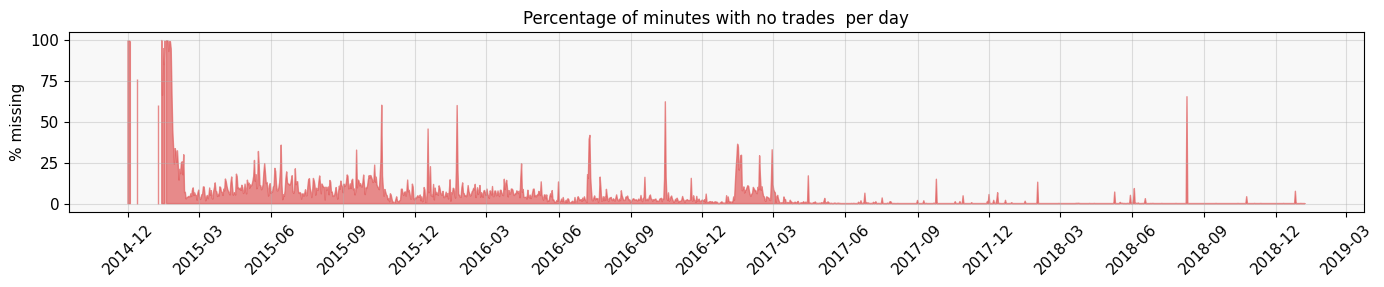

In [16]:
# ============================================================
# 2.1 Daily Missing-Value Distribution
# ============================================================
# This visualization shows how missing trading minutes are distributed
# through time. Concentrated gaps may indicate periods of low liquidity.

# Convert Unix timestamps into datetime format for time-based analysis.
df_raw['datetime']   = pd.to_datetime(df_raw['Timestamp'], unit='s')

# Mark rows where the Close price is missing.
df_raw['is_missing'] = df_raw['Close'].isna().astype(int)

# Calculate the percentage of missing minutes per day.
daily_missing = (
    df_raw.set_index('datetime')['is_missing']
    .resample('D').mean() * 100
)

# Plot daily missing-minute percentage.
fig, ax = plt.subplots(figsize=(14, 3))
ax.fill_between(daily_missing.index, daily_missing.values,
                alpha=0.7, color='#e05c5c')
ax.set_title('Percentage of Minutes With No Recorded Trades per Day', fontsize=12)
ax.set_ylabel('% missing')
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)
plt.tight_layout()

# Save the figure for reporting and documentation.
plt.savefig(DRIVE_PATH + 'missing_per_day.png', dpi=150, bbox_inches='tight')
plt.show()


### 2.2 Interpretation of Temporal Missingness

The missing-minute visualization helps determine whether gaps are random or concentrated in specific periods. Concentrated missingness in earlier years usually reflects lower market activity and weaker liquidity.

For a forecasting model, long inactive stretches are important because forward-filling over many consecutive hours can create artificial flat price segments. These segments may be misleading if the model interprets them as real price stability rather than missing market activity.

Therefore, long gap analysis is needed before finalizing the preprocessing strategy.


In [17]:
# ============================================================
# 2.2 Longest Consecutive Missing Gaps
# ============================================================
# This cell identifies the longest uninterrupted sequences of missing
# Close prices. Long gaps require special attention because they can
# introduce artificial flat signals after forward-filling.

# Boolean mask identifying rows with missing Close values.
is_missing  = df_raw['Close'].isna()

# Assign a group id every time the missing/non-missing status changes.
groups      = is_missing.ne(is_missing.shift()).cumsum()

# Count the length of each consecutive missing segment.
gap_lengths = is_missing[is_missing].groupby(groups[is_missing]).count()

# Display the longest missing gaps.
top_gaps = gap_lengths.sort_values(ascending=False).head(10)
print('Top 10 longest consecutive NaN gaps (minutes):')
print(top_gaps.values)
print()
print(f'Longest gap : {top_gaps.iloc[0]:,} minutes = {top_gaps.iloc[0]/60:.1f} hours')


Top 10 longest consecutive NaN gaps (minutes):
[2303 2142 1358 1326 1222 1050 1023  957  939  901]

Longest gap : 2,303 minutes = 38.4 hours


### 2.3 Interpretation of Maximum Gap Length

The longest uninterrupted missing sequence indicates the maximum amount of time where the market data would need to be forward-filled.

If this gap is very large, forward-fill may create a long artificial plateau. This can reduce the quality of the training data because the model may learn unrealistic price behavior.

A clean forecasting dataset should avoid long inactive periods when possible, especially when the objective is short-term price prediction.


## 3. Time-Series Regularity Check

A sequence forecasting model requires observations to be equally spaced in time. The previous section checked rows that exist in the CSV but contain missing values.

This section checks a different issue: whether some timestamps are completely absent from the file. These hidden gaps cannot be detected by `isna()` alone because the corresponding rows do not exist.

The goal is to verify whether the dataset follows a complete 60-second time grid.


In [18]:
# ============================================================
# 3. Timestamp Difference Analysis
# ============================================================
# This cell calculates the time difference between consecutive rows.
# A perfectly regular 1-minute dataset should have a difference of
# exactly 60 seconds between all consecutive timestamps.

# Sort timestamps and calculate consecutive differences in seconds.
ts    = df_raw['Timestamp'].sort_values().reset_index(drop=True)
diffs = ts.diff().dropna()

print('Timestamp diff distribution (seconds):')
print(diffs.value_counts().head(10))
print()

# Identify all intervals that are not exactly 60 seconds.
non_60 = diffs[diffs != 60]
print(f'Rows with diff ≠ 60 seconds: {len(non_60):,}')

if len(non_60) > 0:
    print('
Largest irregular gaps (seconds):')
    print(non_60.sort_values(ascending=False).head(8).values)


Timestamp diff distribution (seconds):
Timestamp
60.0         2099751
172380.0           1
247500.0           1
101760.0           1
175620.0           1
580200.0           1
1744080.0          1
371940.0           1
108240.0           1
Name: count, dtype: int64

Rows with diff ≠ 60 seconds: 8

Largest irregular gaps (seconds):
[1744080.  580200.  371940.  247500.  175620.  172380.  108240.  101760.]


In [19]:
# ============================================================
# 3.1 Expected vs. Actual Number of Rows
# ============================================================
# This calculation estimates how many rows should exist if every
# 60-second timestamp between the first and last record were present.

# Determine the full timestamp range.
ts_start      = df_raw['Timestamp'].min()
ts_end        = df_raw['Timestamp'].max()

# Expected number of rows in a complete 1-minute time grid.
expected_rows = (ts_end - ts_start) // 60 + 1
actual_rows   = len(df_raw)

print(f'Dataset spans : {pd.to_datetime(ts_start, unit="s")} → {pd.to_datetime(ts_end, unit="s")}')
print(f'Expected rows : {expected_rows:,}  (complete 60-second grid)')
print(f'Actual rows   : {actual_rows:,}')
print(f'Missing rows  : {expected_rows - actual_rows:,}  (timestamps absent from CSV entirely)')


Dataset spans : 2014-12-01 05:33:00 → 2019-01-07 22:06:00
Expected rows : 2,158,114  (complete 60-second grid)
Actual rows   : 2,099,760
Missing rows  : 58,354  (timestamps absent from CSV entirely)


### 3.2 Interpretation of Time-Grid Completeness

The dataset may contain two forms of missing information:

| Type | Meaning |
|------|---------|
| NaN rows | Timestamp exists, but market values are missing |
| Absent timestamp rows | Timestamp does not exist in the CSV at all |

This distinction is important because absent timestamps must be restored by reindexing the data to a complete 60-second datetime grid. Only after reindexing should missing values be filled.

The correct order is:

1. Convert timestamps to datetime.
2. Reindex to a complete 1-minute grid.
3. Forward-fill market values.
4. Remove or trim periods with excessively long inactive gaps if needed.


## 4. Feature Analysis

This section evaluates the predictive usefulness of the available columns. The goal is to identify which features provide independent information and which features are redundant.

For price forecasting, highly correlated columns can increase model complexity without adding meaningful signal. Volume and time-based features may provide additional context if they are transformed properly.


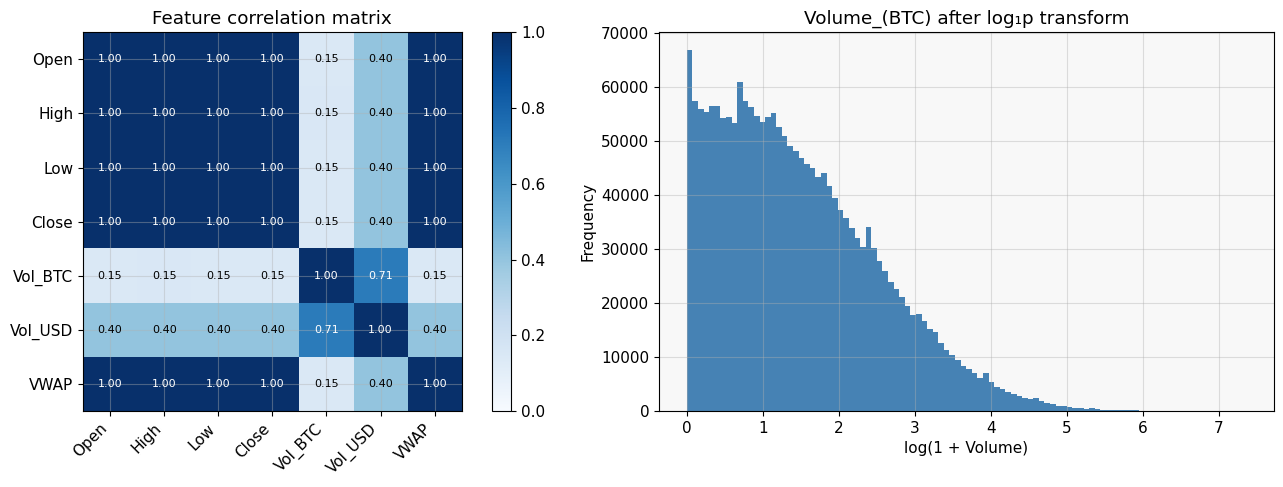

Volume_(BTC) vs Close     : 0.1479
Weighted_Price vs Close   : 1.0000
Open vs Close             : 1.0000


In [20]:
# ============================================================
# 4. Feature Correlation and Volume Distribution
# ============================================================
# This cell examines relationships between numeric market features and
# visualizes the distribution of BTC trading volume after log transform.

# Remove rows with missing values for feature-level analysis.
df_clean = df_raw.dropna().copy()

# Select numeric market columns available in the raw dataset.
cols = ['Open', 'High', 'Low', 'Close', 'Volume_(BTC)', 'Volume_(Currency)', 'Weighted_Price']

# Compute feature correlations.
corr = df_clean[cols].corr().round(4)

# Create side-by-side plots: correlation matrix and volume distribution.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Correlation heatmap.
im = axes[0].imshow(corr, cmap='Blues', vmin=0, vmax=1)
axes[0].set_xticks(range(len(cols)))
axes[0].set_yticks(range(len(cols)))
axes[0].set_xticklabels(['Open','High','Low','Close','Vol_BTC','Vol_USD','VWAP'],
                         rotation=45, ha='right')
axes[0].set_yticklabels(['Open','High','Low','Close','Vol_BTC','Vol_USD','VWAP'])
axes[0].set_title('Feature Correlation Matrix')

# Write correlation values inside the heatmap cells.
for i in range(len(cols)):
    for j in range(len(cols)):
        axes[0].text(j, i, f'{corr.iloc[i,j]:.2f}', ha='center', va='center',
                     fontsize=8, color='white' if corr.iloc[i,j] > 0.7 else 'black')
plt.colorbar(im, ax=axes[0])

# Log-transform BTC volume to reduce the effect of extreme spikes.
log_vol = np.log1p(df_clean['Volume_(BTC)'])
axes[1].hist(log_vol, bins=100, color='steelblue', edgecolor='none')
axes[1].set_title('Volume_(BTC) After log1p Transform')
axes[1].set_xlabel('log(1 + Volume)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()

# Save the feature analysis figure.
plt.savefig(DRIVE_PATH + 'feature_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


### 4.1 Feature Selection Decisions

The correlation analysis supports the following feature decisions:

| Feature | Decision | Reason |
|---------|----------|--------|
| `Close` | Retain | Main target variable for price forecasting |
| `Open`, `High`, `Low` | Remove | Almost perfectly correlated with `Close`; limited additional signal |
| `Weighted_Price` | Remove | Derived price measure; largely duplicates the close-price signal |
| `Volume_(BTC)` | Retain after `log1p` transform | Provides independent trading-activity information |
| `Volume_(Currency)` | Remove | Strongly dependent on price and BTC volume |
| `Timestamp` | Transform | Useful after conversion into cyclical time features |

The final model-ready feature set should focus on price, transformed volume, and cyclical time representations. Cyclical encoding is preferred because it preserves the circular nature of time, such as the closeness between 23:00 and 00:00.


## 5. Final Summary of Data Preparation Decisions

The exploratory analysis leads to the following preprocessing strategy:

| Decision | Justification |
|----------|---------------|
| Reindex to a complete 60-second datetime grid | Restores timestamps that are absent from the raw CSV |
| Forward-fill missing market values | Preserves the regular time structure required by sequence models |
| Avoid very long inactive periods | Prevents artificial flat price segments from dominating training |
| Use `Close` as the main price feature and prediction target | Represents the final traded price per interval |
| Remove highly redundant OHLC and derived price columns | Reduces unnecessary feature duplication |
| Apply `log1p` to `Volume_(BTC)` | Compresses extreme volume spikes and improves scale stability |
| Encode time cyclically | Represents daily and weekly periodicity without artificial discontinuities |
| Use chronological train/validation/test splitting | Prevents future information from leaking into training |
| Fit scalers only on training data | Avoids validation and test leakage |

These decisions provide a clean, consistent, and model-ready foundation for BTC/USD price forecasting.
